In [1]:
import sqlite3
import re
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm
from rapidfuzz import fuzz
from rapidfuzz import distance
from collections import defaultdict
from src.similarity_matrix import (
    create_sim_m_heatmap,
    create_sim_m,
)

## Load used data

In [2]:
connection = sqlite3.connect("data/all_hiski_records.sqlite3")
cursor = connection.cursor()

In [ ]:
query = """
    SELECT *
    FROM parish;
"""

cursor.execute(query)

parish_id_to_place = {
    row[0]: {
        "province": row[1],
        "name": row[2],
        "namese": row[3],
        "xpos": row[4],
        "ypos": row[5],
        "lon": row[6],
        "lat": row[7],
        "history": row[8],
    }
    for row in cursor.fetchall()
}

p_id_to_coords = {k: (v["lon"], v["lat"]) for k, v in parish_id_to_place.items()}

Moving record formats metadata

In [4]:
book_migration_directions = pd.read_csv(
    "outputs/csv/book_migration_direction_info.csv"
)

In [5]:
with open("outputs/json/book_ids.json", "r") as fp:
    book_id_to_info = json.load(fp)

In [6]:
file_paths = tuple(Path(
    "outputs/json/all_migration_events_parish_splits_duplicate_info"
).glob("*.jsonl"))

## Events per parish

In [7]:
problem_free_events_per_parish = defaultdict(int)
immigrations_per_parish = defaultdict(int)
emigrations_per_parish = defaultdict(int)

immigrations_year_predictions_per_parish = defaultdict(lambda: defaultdict(int))
emigrations_year_predictions_per_parish = defaultdict(lambda: defaultdict(int))

for file_path in file_paths:
    with open(file_path, "r") as fp:
        for line in fp:
            e = json.loads(line)
            empty_row = True
            if re.search("[a-öA-Ö]{4,}", "".join(e["row_data"])):
                empty_row = False

            if (
                e["duplicate"] == False
                and (e["in/out"] == "in" or e["in/out"] == "out")
                and e["year_prediction"] != 0
                and not empty_row
            ):
                problem_free_events_per_parish[e["parish_id"]] += 1

                if e["in/out"] == "in":
                    immigrations_per_parish[e["parish_id"]] += 1
                    immigrations_year_predictions_per_parish[e["parish_id"]][
                        e["year_prediction"]
                    ] += 1
                elif e["in/out"] == "out":
                    emigrations_per_parish[e["parish_id"]] += 1
                    emigrations_year_predictions_per_parish[e["parish_id"]][
                        e["year_prediction"]
                    ] += 1

In [22]:
immigrations_per_year_per_parish = pd.DataFrame.from_dict(immigrations_year_predictions_per_parish, orient="index").T.sort_index()
emigrations_per_year_per_parish = pd.DataFrame.from_dict(emigrations_year_predictions_per_parish, orient="index").T.sort_index()

## Total number of parishes in OCR immigration data

In [106]:
print(
    "Number of",
    f" - parishes in parishes-table: {len(parish_id_to_place)}",
    f" - parishes not in parishes-table: {len(
        set(problem_free_events_per_parish.keys()).difference(
            set(parish_id_to_place.keys())
        )
    )}",
    f" - parishes in ocr data: {len(tuple(
        k for k, v in problem_free_events_per_parish.items() if v > 0
    ))}",
    f" - parishes in immigrations: {len(immigrations_per_parish)}",
    f" - parishes in emigrations: {len(emigrations_per_parish)}",
    f" - parishes not in common between immigrations and emigrations: {
        len(set(
            immigrations_per_parish.keys()).symmetric_difference(
                set(emigrations_per_parish.keys())
            )
        )
    }",
    sep="\n"
)

Number of
 - parishes in parishes-table: 522
 - parishes not in parishes-table: 38
 - parishes in ocr data: 439
 - parishes in immigrations: 433
 - parishes in emigrations: 427
 - parishes not in common between immigrations and emigrations: 18


## Distribution of events between parishes in OCR data

In [165]:
parish_migration_counts = {
    parish_id_to_place.get(p_id, {"name": "unknown"})["name"]: event_count
    for p_id, event_count in problem_free_events_per_parish.items()
}

parish_immigration_counts = {
    parish_id_to_place.get(p_id, {"name": "unknown"})["name"]: event_count
    for p_id, event_count in immigrations_per_parish.items()
}

parish_emigration_counts = {
    parish_id_to_place.get(p_id, {"name": "unknown"})["name"]: event_count
    for p_id, event_count in emigrations_per_parish.items()
}

In [166]:
print(
    f"min: {min(
        min(parish_immigration_counts.values()),
        min(parish_emigration_counts.values())
    )}",
    f"max: {max(
        max(parish_immigration_counts.values()),
        max(parish_emigration_counts.values())
    )}",
    sep="\n"
)

min: 16
max: 80558


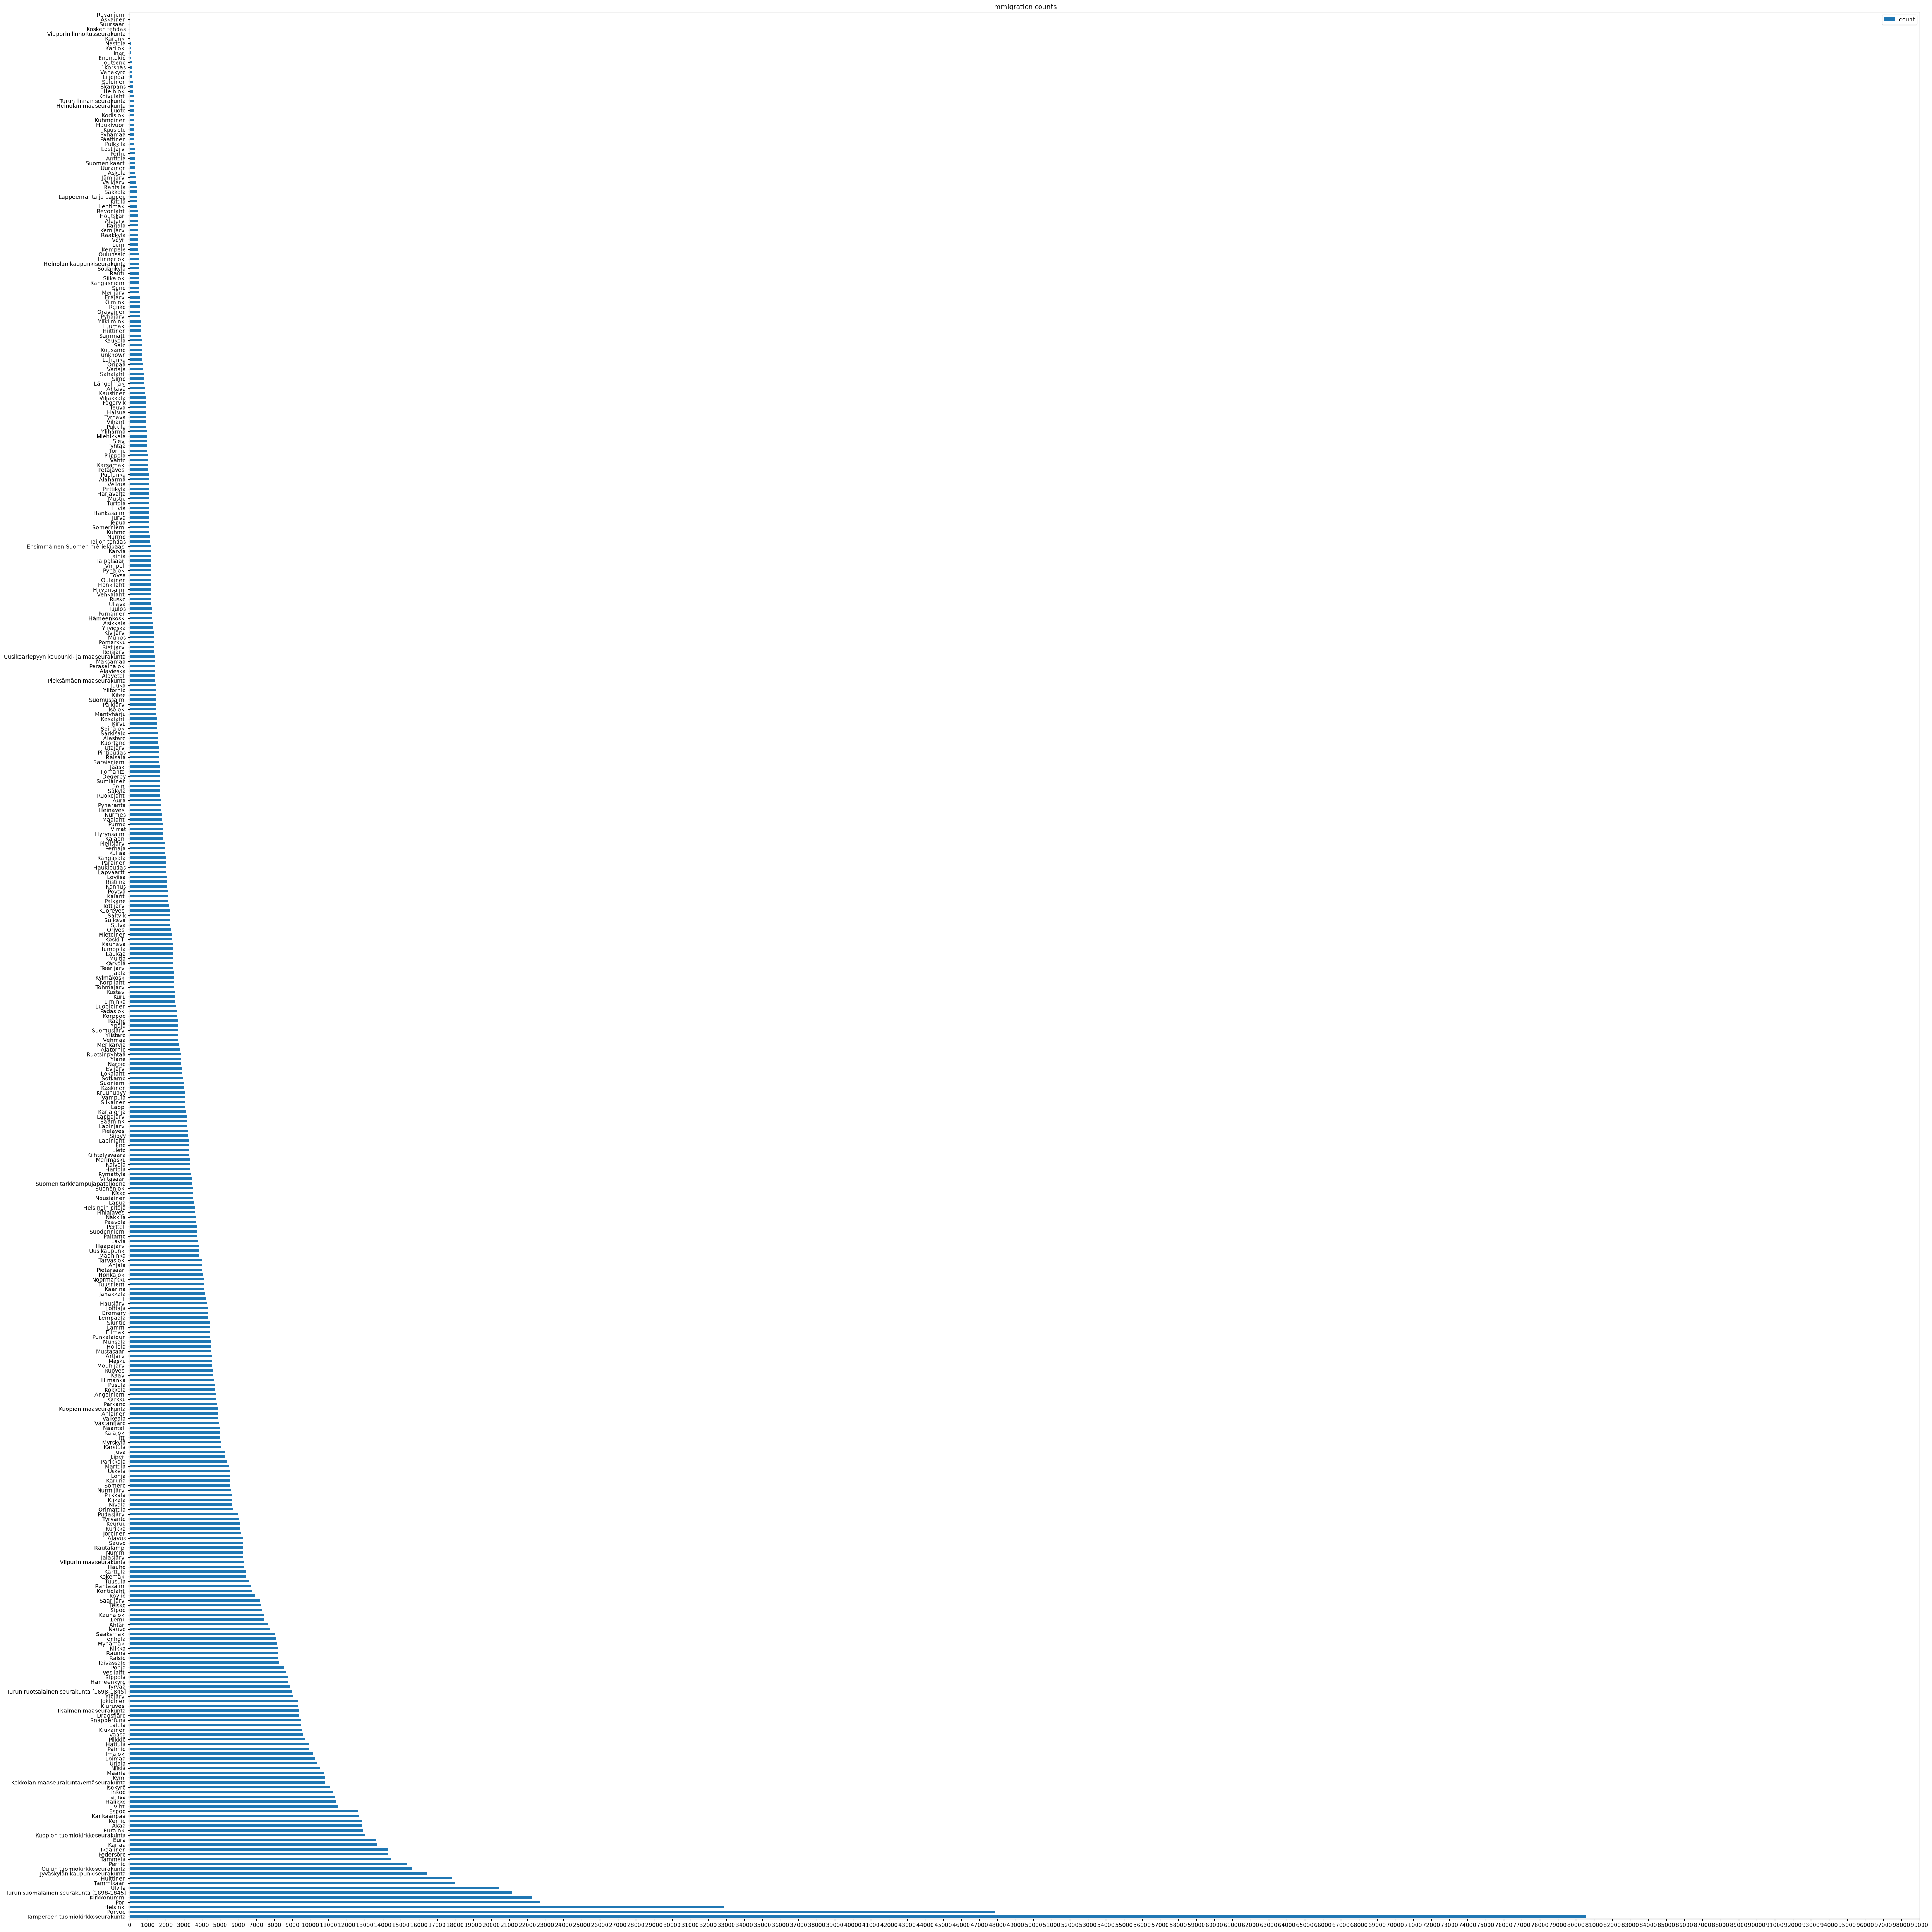

In [172]:
fig, ax = plt.subplots(1, 1, figsize=(50, 50))
pd.DataFrame.from_dict(
    parish_immigration_counts, "index", columns=["count"]
).sort_values("count", ascending=False).plot.barh(y="count", ax=ax)
ax.set_xticks(range(0, 100000, 1000), range(0, 100000, 1000))
ax.set_title("Immigration counts")
fig.tight_layout()

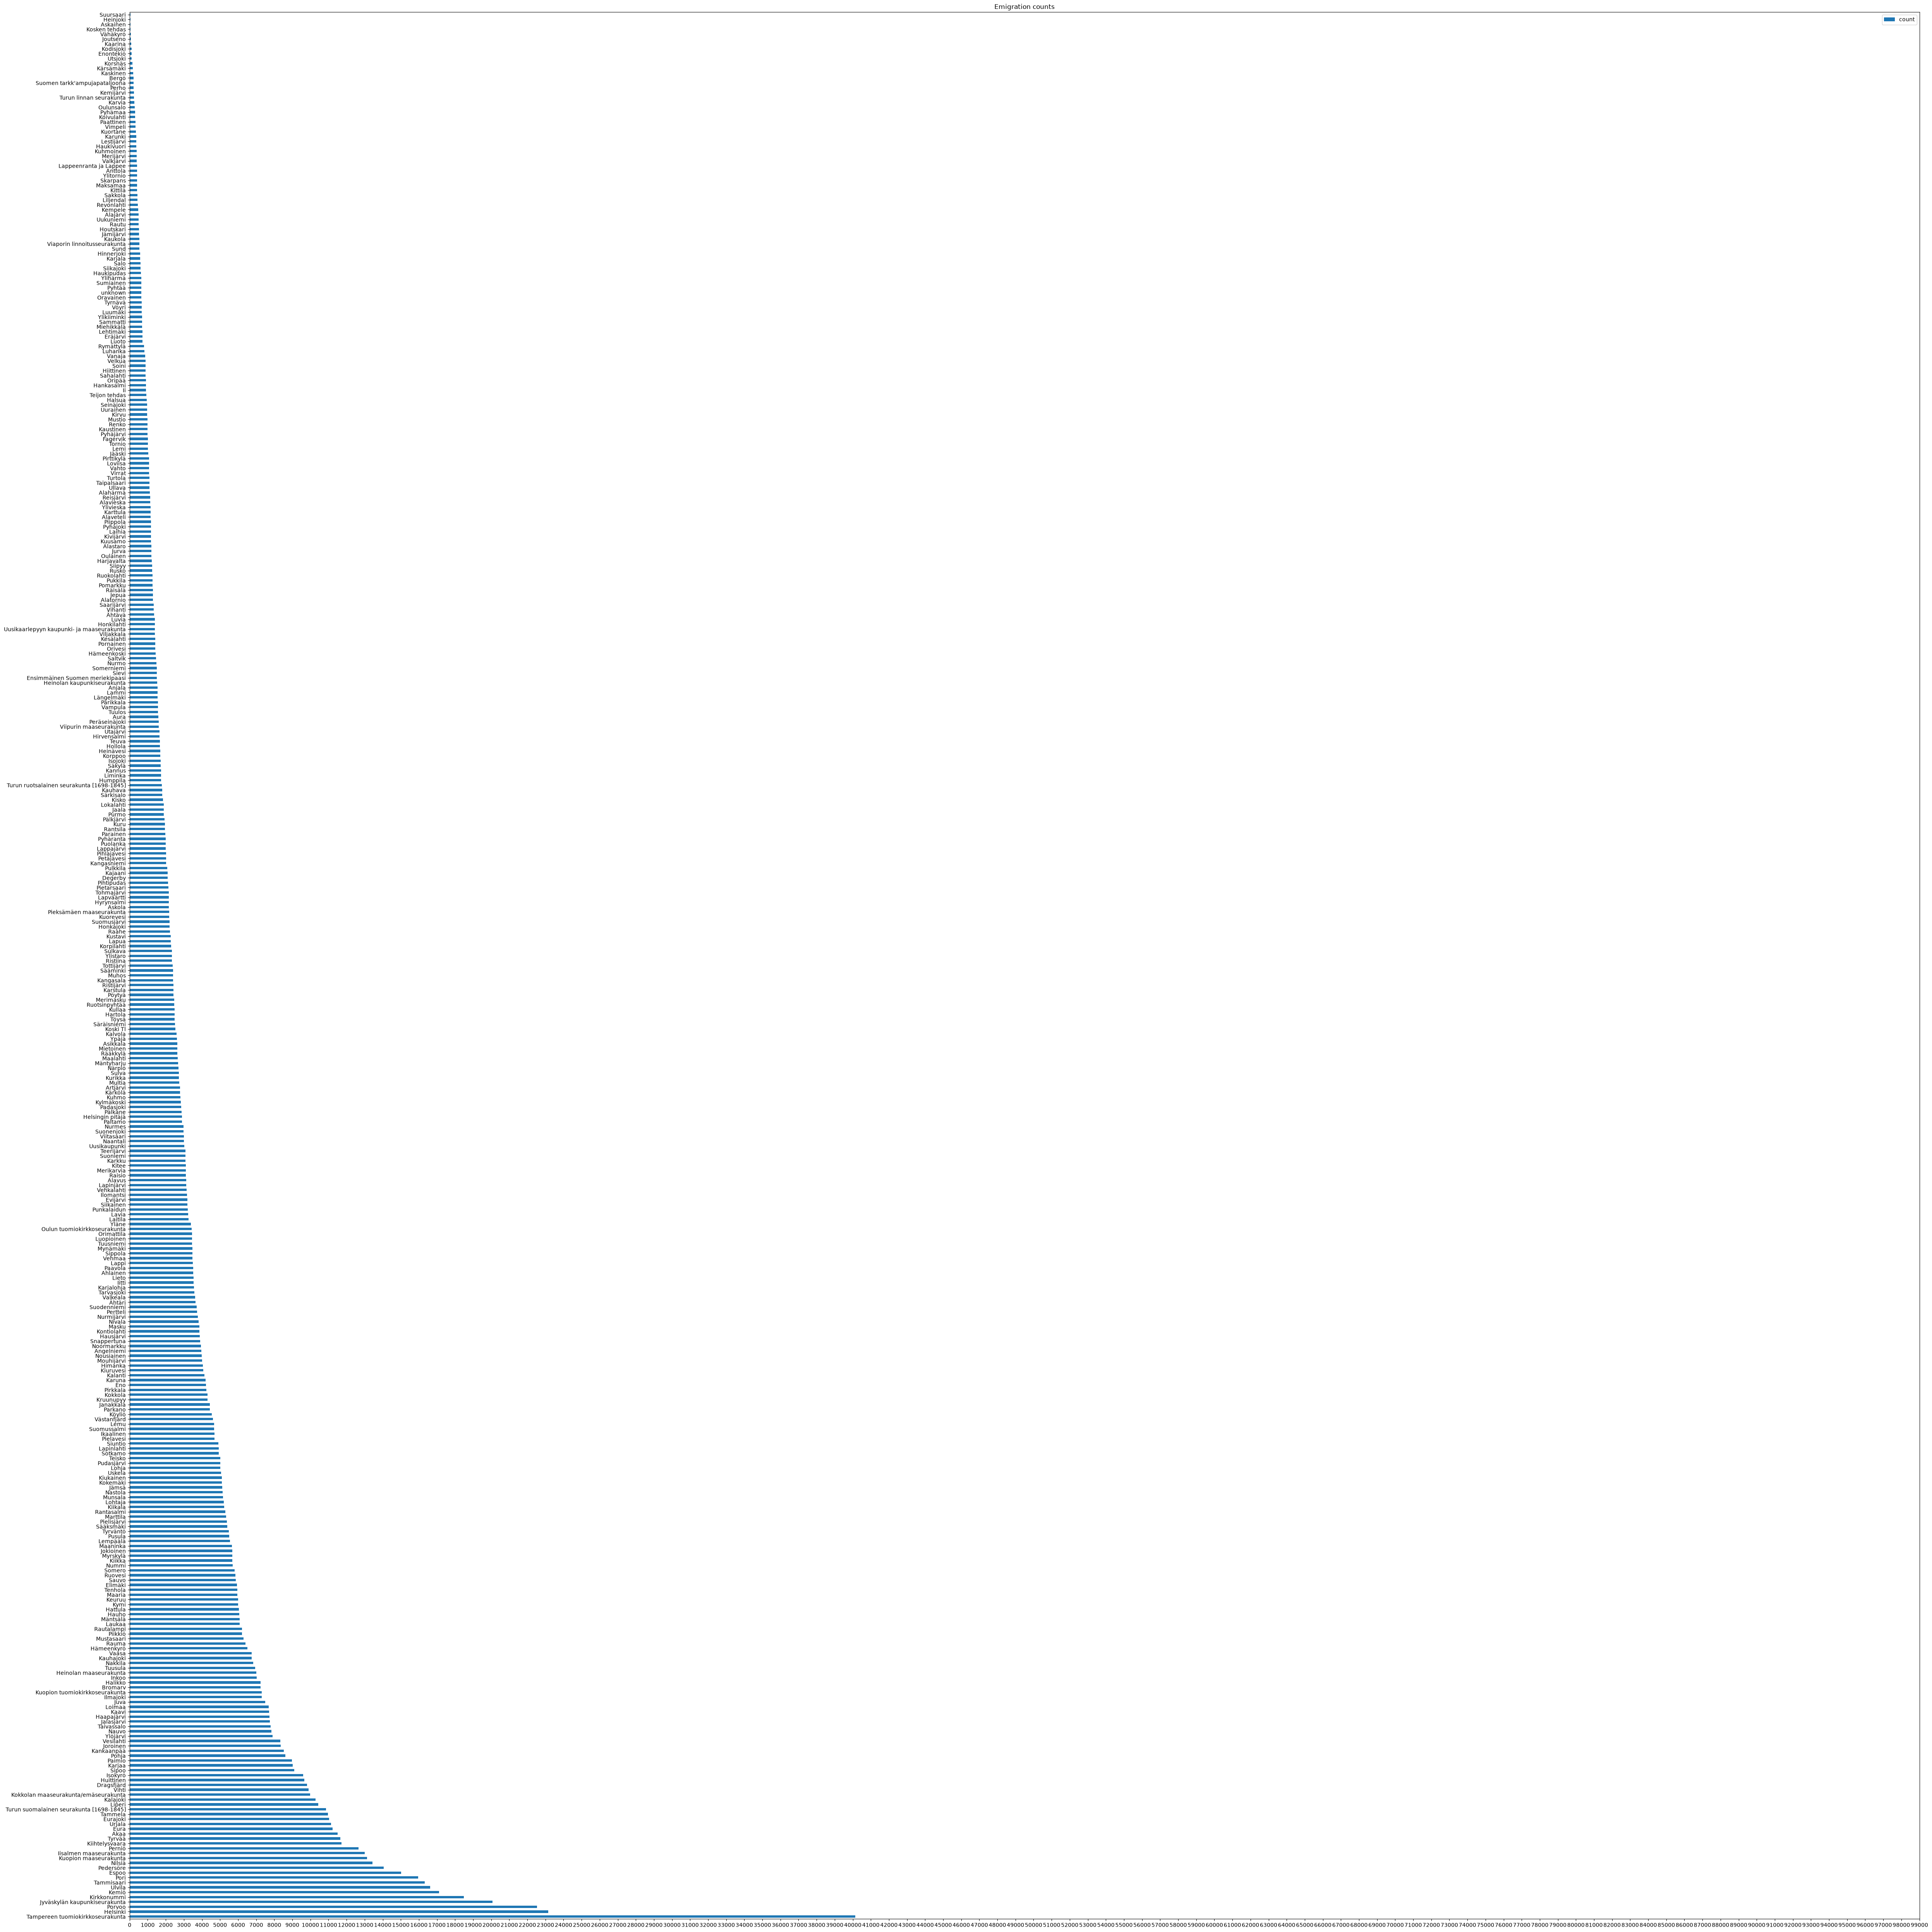

In [173]:
fig, ax = plt.subplots(1, 1, figsize=(50, 50))
pd.DataFrame.from_dict(
    parish_emigration_counts, "index", columns=["count"]
).sort_values("count", ascending=False).plot.barh(y="count", ax=ax)
ax.set_xticks(range(0, 100000, 1000), range(0, 100000, 1000))
ax.set_title("Emigration counts")
fig.tight_layout()

## Top 25 parishes

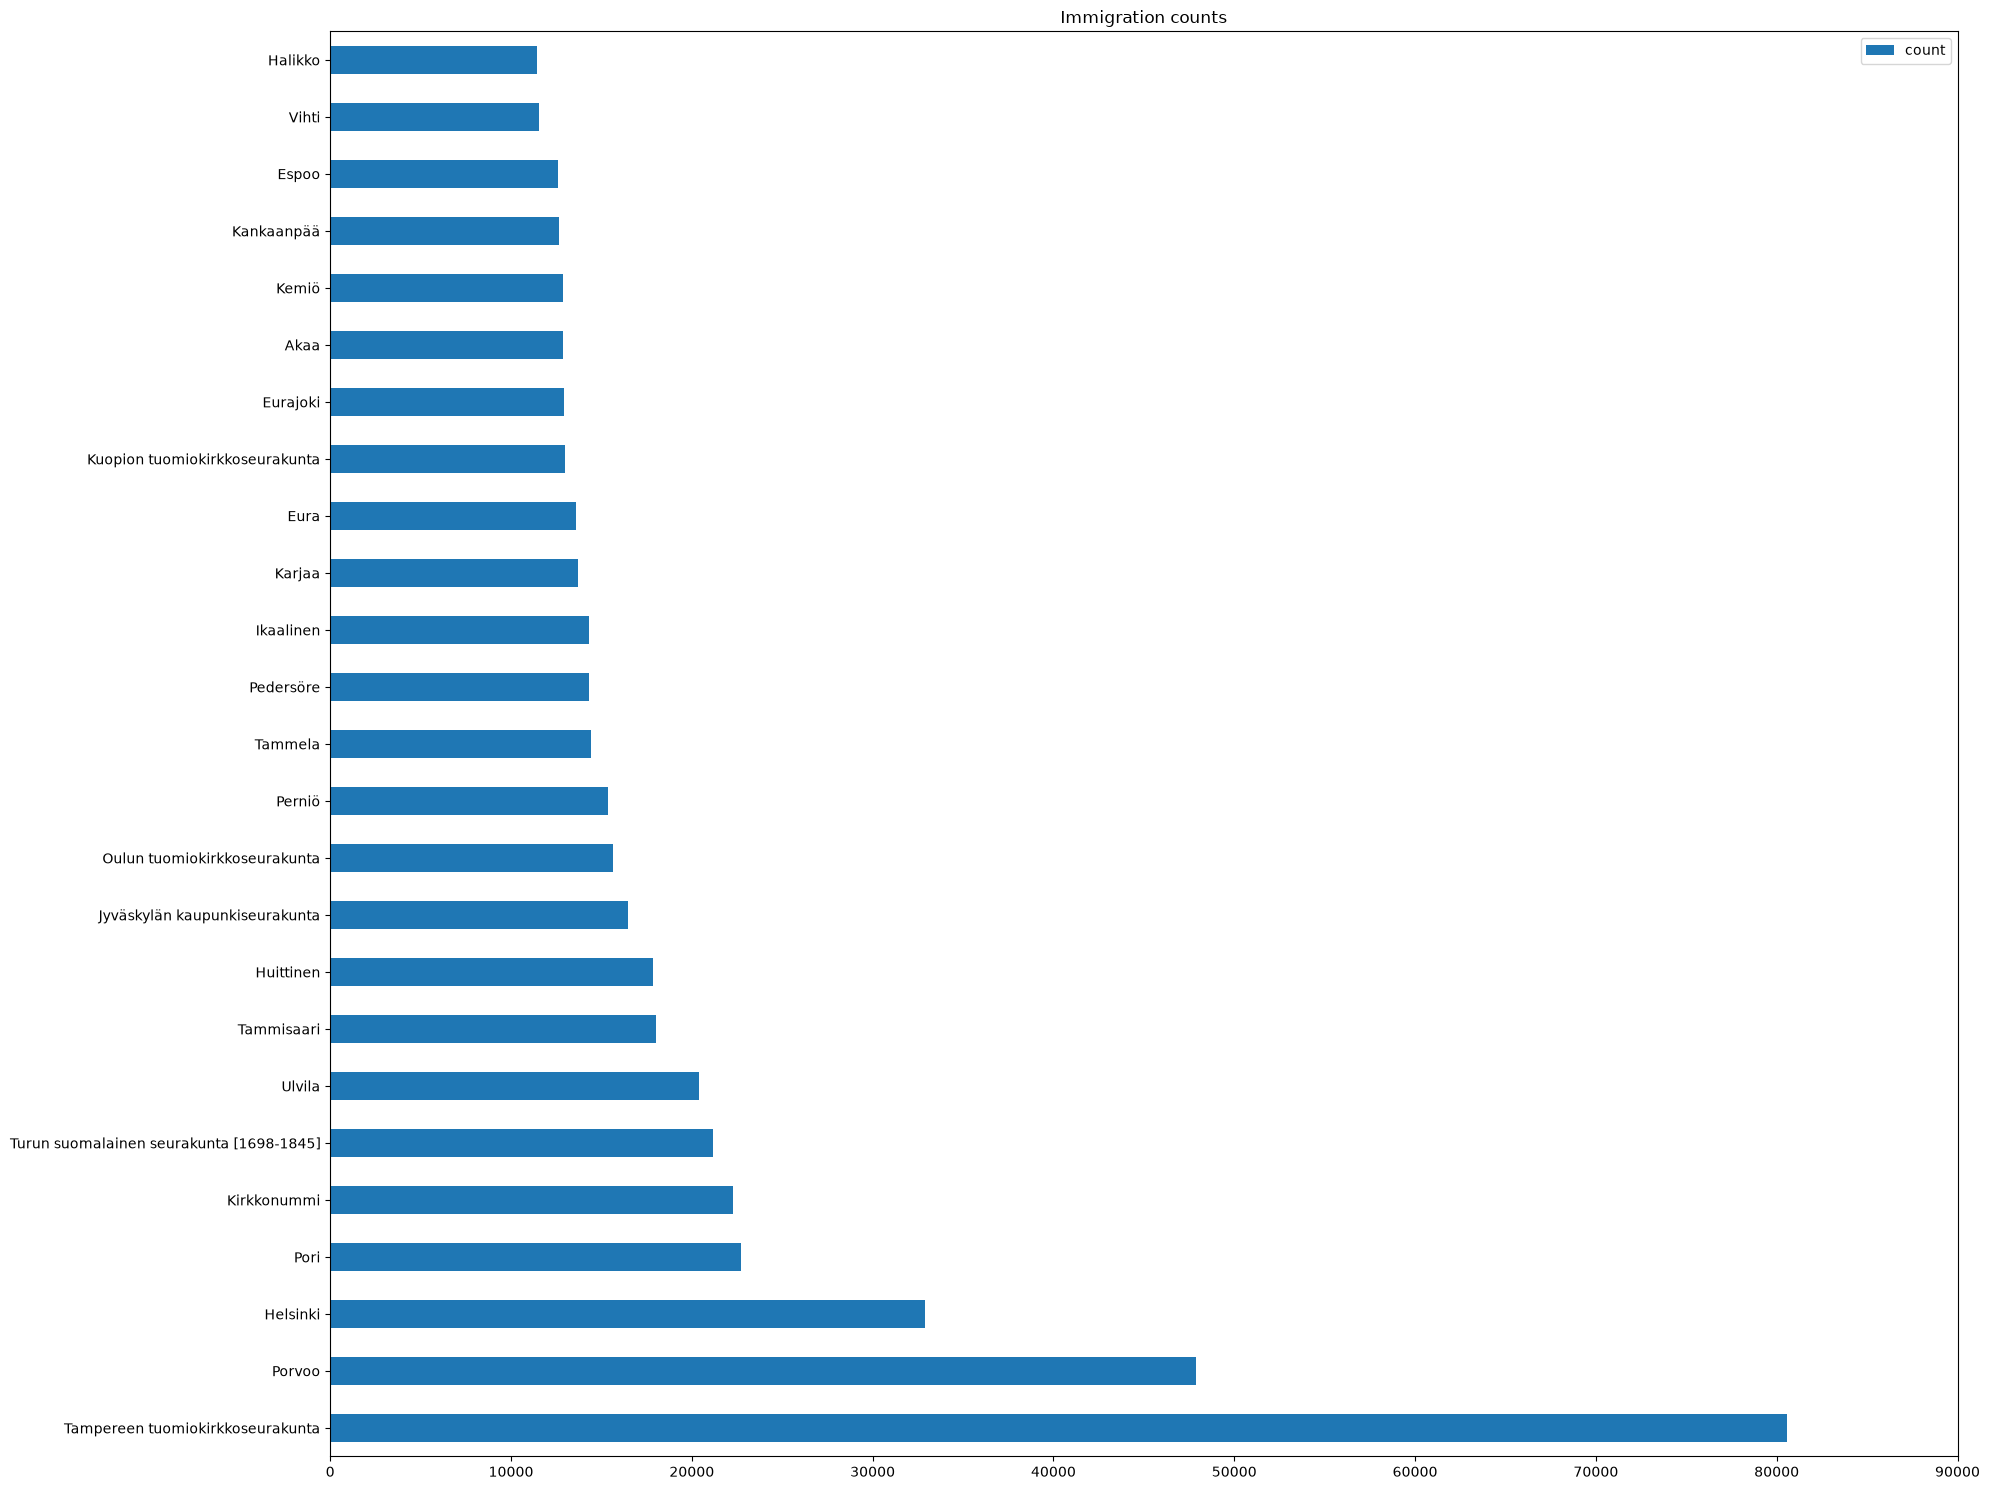

In [181]:
fig, ax = plt.subplots(1, 1, figsize=(20, 15))
pd.DataFrame.from_dict(
    parish_immigration_counts, "index", columns=["count"]
).sort_values("count", ascending=False)[:25].plot.barh(y="count", ax=ax)
ax.set_xticks(range(0, 100000, 10000), range(0, 100000, 10000))
ax.set_title("Immigration counts")
fig.tight_layout()

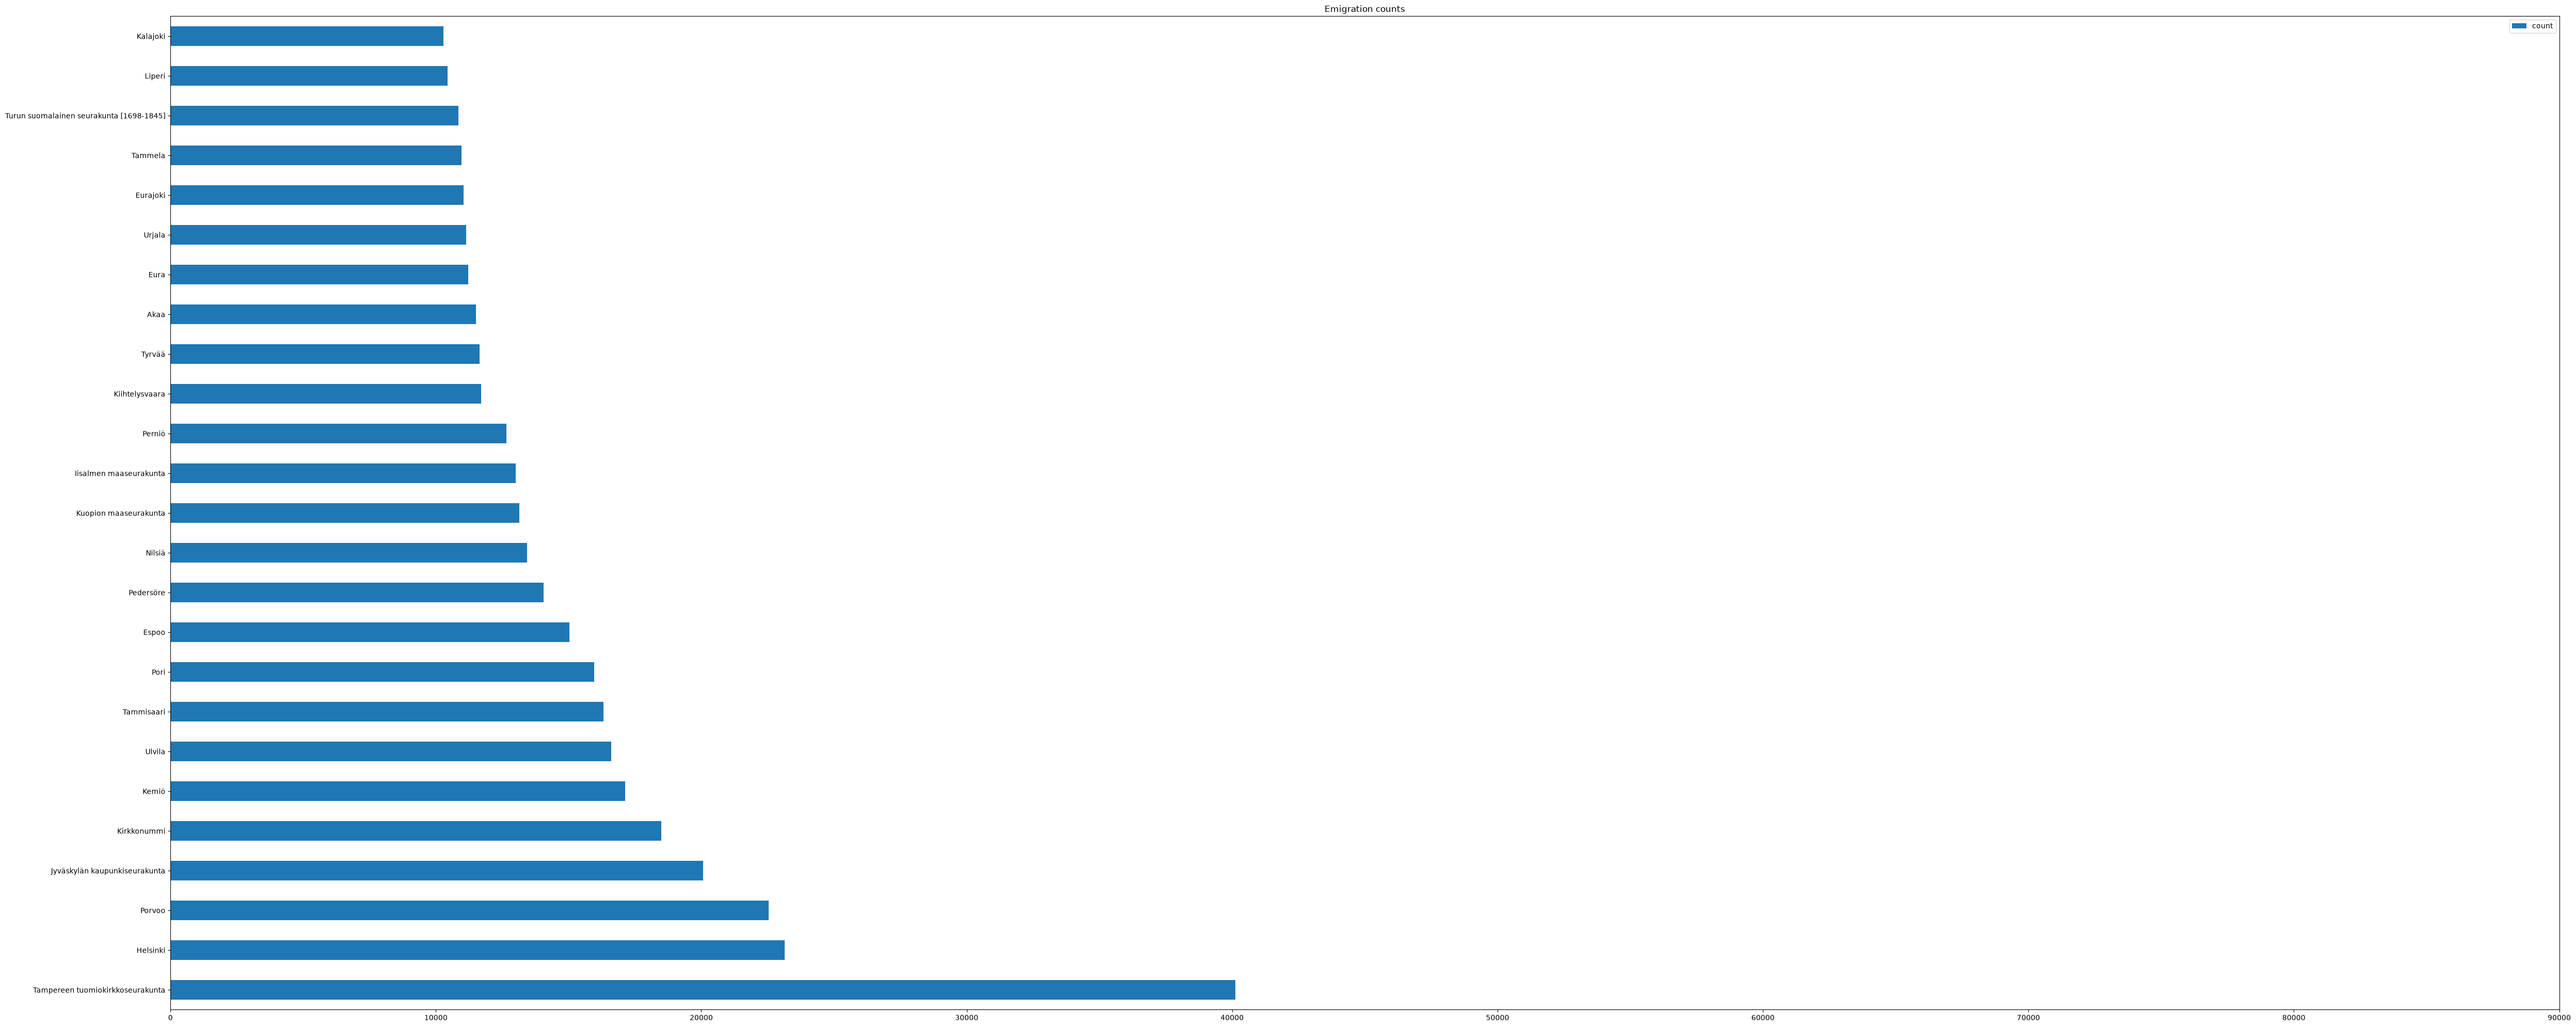

In [182]:
fig, ax = plt.subplots(1, 1, figsize=(50, 20))
pd.DataFrame.from_dict(
    parish_emigration_counts, "index", columns=["count"]
).sort_values("count", ascending=False)[:25].plot.barh(y="count", ax=ax)
ax.set_xticks(range(0, 100000, 10000), range(0, 100000, 10000))
ax.set_title("Emigration counts")
fig.tight_layout()

## OCR parish event counts on map

In [132]:
immigration_parish_e_counts_with_coordinates = pd.DataFrame.from_dict(immigrations_per_parish, 'index', columns=["count"])
immigration_parish_e_counts_with_coordinates["lon"] = (
    immigration_parish_e_counts_with_coordinates.index.map(
        lambda x: parish_id_to_place.get(x, {"lon": None})["lon"]
    )
)
immigration_parish_e_counts_with_coordinates["lat"] = (
    immigration_parish_e_counts_with_coordinates.index.map(
        lambda x: parish_id_to_place.get(x, {"lat": None})["lat"]
    )
)


emigration_parish_e_counts_with_coordinates = pd.DataFrame.from_dict(emigrations_per_parish, 'index', columns=["count"])
emigration_parish_e_counts_with_coordinates["lon"] = (
    emigration_parish_e_counts_with_coordinates.index.map(
        lambda x: parish_id_to_place.get(x, {"lon": None})["lon"]
    )
)
emigration_parish_e_counts_with_coordinates["lat"] = (
    emigration_parish_e_counts_with_coordinates.index.map(
        lambda x: parish_id_to_place.get(x, {"lat": None})["lat"]
    )
)

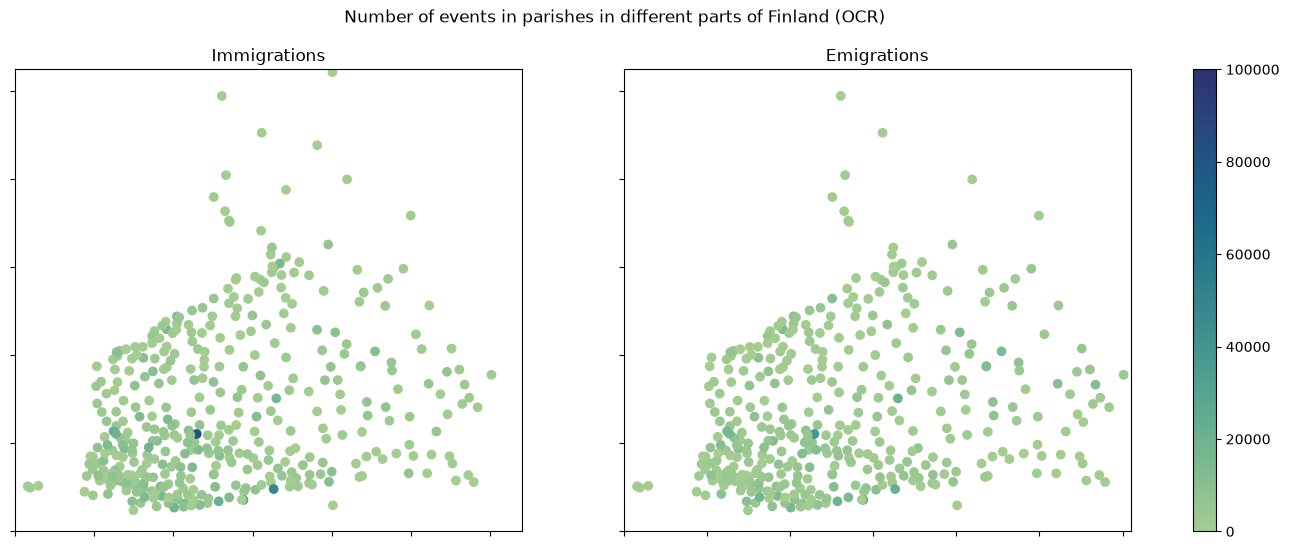

In [150]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Number of events in parishes in different parts of Finland (OCR)")
axs[0].scatter(
    x=immigration_parish_e_counts_with_coordinates["lon"],
    y=immigration_parish_e_counts_with_coordinates["lat"],
    c=immigration_parish_e_counts_with_coordinates["count"],
    cmap=sns.cm.crest,
    vmin=0, vmax=100000
)
axs[0].set_xlim(100000, 740000)
axs[0].set_ylim(6600000, 7650000)
axs[0].set_yticklabels([])
axs[0].set_xticklabels([])
axs[0].set_title("Immigrations")

scatter = axs[1].scatter(
    x=emigration_parish_e_counts_with_coordinates["lon"],
    y=emigration_parish_e_counts_with_coordinates["lat"],
    c=emigration_parish_e_counts_with_coordinates["count"],
    cmap=sns.cm.crest,
    vmin=0, vmax=100000
)
axs[1].set_xlim(100000, 710000)
axs[1].set_ylim(6600000, 7650000)
axs[1].set_yticklabels([])
axs[1].set_xticklabels([])
axs[1].set_title("Emigrations")
fig.colorbar(scatter, ax=axs, fraction=0.05)

In [78]:
sorted(df_in.values[~pd.isna(df_in.values)], reverse=True)[3]

np.float64(4240.0)

In [102]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df_in = immigrations_per_year_per_parish
df_out = emigrations_per_year_per_parish
all_parish_ids = sorted(set(df_out.columns) | set(df_in.columns))
all_years = sorted(set(df_out.index) | set(df_in.index))

df_in = df_in.reindex(index=all_years, columns=all_parish_ids)
df_out = df_out.reindex(index=all_years, columns=all_parish_ids)

years = df_out.index.tolist()

xs = [p_id_to_coords.get(p, [None, None])[0] for p in all_parish_ids]
ys = [p_id_to_coords.get(p, [None, None])[1] for p in all_parish_ids]

cmin = min(
    df_out.values[~pd.isna(df_out.values)].min(),
    df_in.values[~pd.isna(df_in.values)].min()
)
cmax = 500
#cmax = max(
    #df_out.values[~pd.isna(df_out.values)].max(),
    #df_in.values[~pd.isna(df_in.values)].max()
#)

def masked(df, year):
    vals = df.loc[year, all_parish_ids].values
    mx = [x for x, v in zip(xs, vals) if not pd.isna(v)]
    my = [y for y, v in zip(ys, vals) if not pd.isna(v)]
    mc = [v for v in vals if not pd.isna(v)]
    return mx, my, mc

dummy_colorbar = go.Scatter(
    x=[xs[0]], y=[ys[0]], mode="markers",
    marker=dict(color=[cmin, cmax][:1], colorscale="Viridis", cmin=cmin, cmax=cmax,
                showscale=True, opacity=0, size=0.001,
                colorbar=dict(
                    tickvals=tuple(range(0, 501, 100)),
                    ticktext=("0", "100", "200", "300", "400", "500<"),
                )
            ),
    hoverinfo="skip", showlegend=False
)

frames = []
for year in years:
    ox, oy, oc = masked(df_out, year)
    ix, iy, ic = masked(df_in, year)
    frames.append(
        go.Frame(
            data=[
                go.Scatter(
                    x=ox, y=oy,
                    mode="markers",
                    marker=dict(
                        color=oc, colorscale="Viridis",
                        showscale=False, size=10,
                        cmin=cmin, cmax=cmax,
                    ),
                    name=""
                ),
                go.Scatter(
                    x=ix, y=iy,
                    mode="markers",
                    marker=dict(
                        color=ic, colorscale="Viridis",
                        showscale=True, size=10,
                        cmin=cmin, cmax=cmax,
                    ),
                    name=""
                ),
            ],
            name=str(year),
            traces=[0, 1],
        )
    )

fig = make_subplots(
    rows=1, cols=2, subplot_titles=("Emigrations", "Immigrations"), 
)
fig.add_trace(frames[0].data[0], row=1, col=1,)
fig.add_trace(frames[0].data[1], row=1, col=2,)
fig.add_trace(dummy_colorbar, row=1, col=1)
fig.frames = frames

fig.update_xaxes(range=[100000, 740000], showticklabels=False)
fig.update_yaxes(range=[6600000, 7650000], showticklabels=False)

fig.update_layout(
    width=1400,
    height=800,
    sliders=[{
        "steps": [{
            "args": [
                [f.name],
                {
                    "frame": {"duration": 0, "redraw": True},
                    "mode": "immediate",
                },
            ],
            "label": f.name,
            "method": "animate",
        } for f in frames],
        "currentvalue": {"prefix": "Year: "},
    }],
    title="Number of events in parishes in different parts of Finland (OCR)",
    title_x=0.5,
)

fig.show()
fig.write_html("outputs/interactive_migrations_in_finland.html", auto_play=False)